# Olist Dataset EDA

## 필요한 라이브러리 불러오기

In [ ]:
# 표준 라이브러리
from pathlib import Path

# 서드파티 라이브러리
import pandas as pd

## 데이터 불러오기

In [2]:
DATA_PATH = Path('../data/raw/')
customers = pd.read_csv(DATA_PATH / 'olist_customers_dataset.csv')
location = pd.read_csv(DATA_PATH / 'olist_geolocation_dataset.csv')
order_items = pd.read_csv(DATA_PATH / 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(DATA_PATH / 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(DATA_PATH / 'olist_order_reviews_dataset.csv')
orders = pd.read_csv(DATA_PATH / 'olist_orders_dataset.csv')
products = pd.read_csv(DATA_PATH / 'olist_products_dataset.csv')
sellers = pd.read_csv(DATA_PATH / 'olist_sellers_dataset.csv')
category = pd.read_csv(DATA_PATH / 'product_category_name_translation.csv')

## Orders 탐색

In [4]:
orders.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01 00:00:00
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07 00:00:00
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06 00:00:00
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23 00:00:00


In [5]:
orders.shape

(99441, 8)

In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [7]:
orders.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], format='%Y-%m-%d %H:%M:%S')

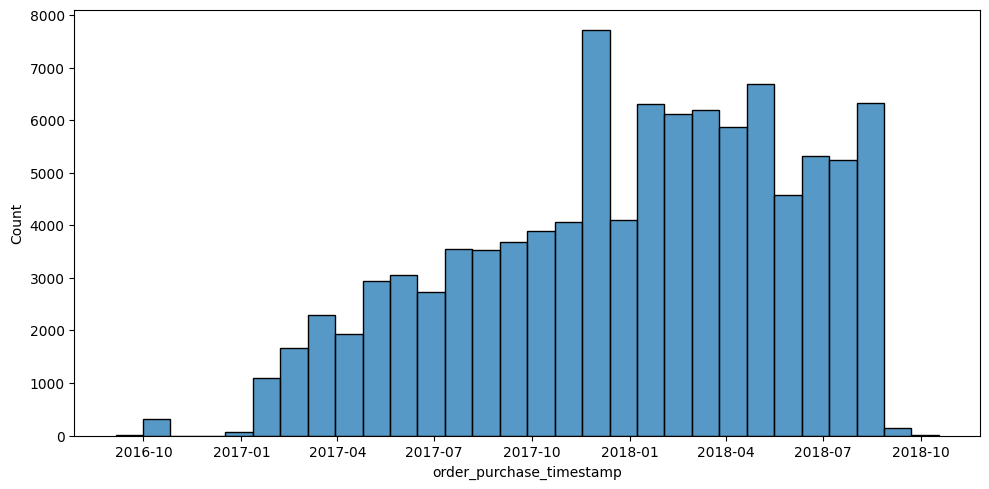

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(orders['order_purchase_timestamp'], bins=30)

plt.tight_layout()
plt.show()

## Customers 탐색

In [10]:
customers.head(10)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
5,879864dab9bc3047522c92c82e1212b8,4c93744516667ad3b8f1fb645a3116a4,89254,jaragua do sul,SC
6,fd826e7cf63160e536e0908c76c3f441,addec96d2e059c80c30fe6871d30d177,4534,sao paulo,SP
7,5e274e7a0c3809e14aba7ad5aae0d407,57b2a98a409812fe9618067b6b8ebe4f,35182,timoteo,MG
8,5adf08e34b2e993982a47070956c5c65,1175e95fb47ddff9de6b2b06188f7e0d,81560,curitiba,PR
9,4b7139f34592b3a31687243a302fa75b,9afe194fb833f79e300e37e580171f22,30575,belo horizonte,MG


In [11]:
customers.shape

(99441, 5)

In [12]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [13]:
customers.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [14]:
# 재구매율 계산
grouped = customers.groupby('customer_unique_id').agg(cnt_order=('customer_id', 'count'))
reorder_cond = grouped['cnt_order'] > 1
grouped[reorder_cond].size / grouped.size * 100

3.1187562437562435

In [15]:
location.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [16]:
location.shape

(1000163, 5)

In [17]:
location.duplicated().value_counts()

False    738332
True     261831
Name: count, dtype: int64

In [18]:
location.duplicated(subset=['geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state']).value_counts()

True     972251
False     27912
Name: count, dtype: int64

## Order Items 살펴보기

In [19]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [20]:
order_items.shape

(112650, 7)

In [21]:
order_items['order_id'].nunique()

98666

In [22]:
order_items.duplicated(subset=['order_id', 'order_item_id']).value_counts()

False    112650
Name: count, dtype: int64

In [8]:
order_items.groupby('order_id').agg({'order_item_id': 'min'}).sort_values('order_item_id', ascending=False)

,order_item_id
order_id,
fffe41c64501cc87c801fd61db3f6244,1
00010242fe8c5a6d1ba2dd792cb16214,1
00018f77f2f0320c557190d7a144bdd3,1
000229ec398224ef6ca0657da4fc703e,1
00024acbcdf0a6daa1e931b038114c75,1
...,...
0009792311464db532ff765bf7b182ae,1
0008288aa423d2a3f00fcb17cd7d8719,1
0006ec9db01a64e59a68b2c340bf65a7,1


## Orders Payments 살펴보기

In [23]:
order_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [24]:
order_payments.shape

(103886, 5)

In [25]:
order_payments.nunique()

order_id                99440
payment_sequential         29
payment_type                5
payment_installments       24
payment_value           29077
dtype: int64

In [26]:
print(order_payments['payment_type'].value_counts())

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [27]:
order_payments['payment_sequential'].value_counts()

payment_sequential
1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
17        6
19        6
18        6
16        6
20        4
21        4
22        3
24        2
25        2
26        2
23        2
27        1
28        1
29        1
Name: count, dtype: int64

In [28]:
order_payments.duplicated(subset=['order_id', 'payment_sequential']).value_counts()

False    103886
Name: count, dtype: int64

In [29]:
order_payments['payment_installments'].value_counts(ascending=True)

payment_installments
22        1
23        1
0         2
21        3
16        5
17        8
14       15
13       16
20       17
24       18
11       23
18       27
15       74
12      133
9       644
7      1626
6      3920
8      4268
5      5239
10     5328
4      7098
3     10461
2     12413
1     52546
Name: count, dtype: int64

In [30]:
order_payments.groupby('order_id').agg({'payment_sequential': 'min'}).value_counts()

payment_sequential
1                     99360
2                        80
Name: count, dtype: int64

In [12]:
seq_grouped = order_payments.groupby('order_id').agg({'payment_sequential': 'min'})
seq_grouped[seq_grouped['payment_sequential'] == 2]

,payment_sequential
order_id,
00ac05fe0fc047c54418098eb64e3aaa,2
056c68d093c100017aab1f00f260705c,2
0668d086b3ae41adde3aed3dacbc8fae,2
0a7d898c6305101e69e9f5a05cd0130d,2
0d0e88a418636d40ea780339701db49c,2
...,...
f0f94b7c7548150f33f5d9e7597d396f,2
f17a58e669a7f4cf7a7f227899f8abf7,2
f5691c2b1ca263490374d13d020bd950,2


In [13]:
order_payments[order_payments['order_id'] == '00ac05fe0fc047c54418098eb64e3aaa']

,order_id,payment_sequential,payment_type,payment_installments,payment_value
27191,00ac05fe0fc047c54418098eb64e3aaa,2,debit_card,1,123.47


In [31]:
order_payments.groupby('order_id').agg({'payment_sequential': 'count', 'payment_type': 'count'})

,payment_sequential,payment_type
order_id,,
00010242fe8c5a6d1ba2dd792cb16214,1,1
00018f77f2f0320c557190d7a144bdd3,1,1
000229ec398224ef6ca0657da4fc703e,1,1
00024acbcdf0a6daa1e931b038114c75,1,1
00042b26cf59d7ce69dfabb4e55b4fd9,1,1
...,...,...
fffc94f6ce00a00581880bf54a75a037,1,1
fffcd46ef2263f404302a634eb57f7eb,1,1
fffce4705a9662cd70adb13d4a31832d,1,1


In [32]:
grouped = order_payments.groupby('order_id').agg({'payment_sequential': 'min', 'payment_type': 'count'})
grouped[grouped['payment_sequential'] == 2]

,payment_sequential,payment_type
order_id,,
00ac05fe0fc047c54418098eb64e3aaa,2,1
056c68d093c100017aab1f00f260705c,2,1
0668d086b3ae41adde3aed3dacbc8fae,2,1
0a7d898c6305101e69e9f5a05cd0130d,2,1
0d0e88a418636d40ea780339701db49c,2,1
...,...,...
f0f94b7c7548150f33f5d9e7597d396f,2,1
f17a58e669a7f4cf7a7f227899f8abf7,2,1
f5691c2b1ca263490374d13d020bd950,2,1


In [33]:
order_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [34]:
order_reviews.shape

(99224, 7)

In [35]:
order_reviews.nunique()

review_id                  98410
order_id                   98673
review_score                   5
review_comment_title        4527
review_comment_message     36159
review_creation_date         636
review_answer_timestamp    98248
dtype: int64

In [36]:
order_reviews['review_comment_message']

0                                                      NaN
1                                                      NaN
2                                                      NaN
3                    Recebi bem antes do prazo estipulado.
4        Parabéns lojas lannister adorei comprar pela I...
                               ...                        
99219                                                  NaN
99220                                                  NaN
99221    Excelente mochila, entrega super rápida. Super...
99222                                                  NaN
99223    meu produto chegou e ja tenho que devolver, po...
Name: review_comment_message, Length: 99224, dtype: object

In [37]:
order_reviews.duplicated(subset=['review_id', 'order_id']).value_counts()

False    99224
Name: count, dtype: int64

In [38]:
order_reviews[order_reviews.duplicated(subset=['review_id'])]

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
3317,3242cc306a9218d0377831e175d62fbf,9c5bfba7de6a4abbb6ba0baab78d1622,5,NaN,Ótimo,2017-07-21 00:00:00,2017-07-22 01:06:37
5719,308316408775d1600dad81bd3184556d,3fe4dbcdb046a475dbf25463c1ca78bd,5,NaN,Ajudem a rastrear uma das 3 prateleiras que fa...,2017-09-07 00:00:00,2017-09-11 09:58:09
7213,8ee90ac383cf825bb7f4756130d4e74a,75d5d3d16567a27eefc5752aeb063072,5,NaN,recomendo,2017-05-30 00:00:00,2017-06-02 18:16:17
7805,d433c252647c51309432ca0b763f969b,191abde9c3bf77d1ce67d100d8db6d15,1,NaN,NaN,2017-09-03 00:00:00,2017-09-06 16:11:00
9013,03a6a25db577d0689440933055111897,3fde8b7313af6b37b84b5c7594d7add0,5,NaN,Muito Bom! Gostei Bastante! Tecido Ótimo! Aten...,2017-12-15 00:00:00,2017-12-16 01:32:18
...,...,...,...,...,...,...,...
99108,2c6c08892b83ba4c1be33037c2842294,42ae1967f68c90bb325783ac55d761ce,4,NaN,"Chegou um pouco amassada, mas nada de mais, e ...",2017-07-03 00:00:00,2017-07-05 19:06:59
99124,6ec93e77f444e0b1703740a69122e35d,e1fdc6e9d1ca132377e862593a7c0bd4,5,NaN,Vendedor compromisso do vou o cliente,2017-10-07 00:00:00,2017-10-07 19:47:11
99164,2afe63a67dfd99b3038f568fb47ee761,c5334d330e36d2a810a7a13c72e135ee,5,NaN,"Muito bom, produto conforme anunciado, entrega...",2018-03-03 00:00:00,2018-03-04 22:56:47
99167,017808d29fd1f942d97e50184dfb4c13,b1461c8882153b5fe68307c46a506e39,5,NaN,NaN,2018-03-02 00:00:00,2018-03-05 01:43:30


In [39]:
order_reviews[order_reviews['review_id'] == '3242cc306a9218d0377831e175d62fbf']

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
1009,3242cc306a9218d0377831e175d62fbf,711246846695fa895c1776f0ddc30b20,5,NaN,Ótimo,2017-07-21 00:00:00,2017-07-22 01:06:37
3317,3242cc306a9218d0377831e175d62fbf,9c5bfba7de6a4abbb6ba0baab78d1622,5,NaN,Ótimo,2017-07-21 00:00:00,2017-07-22 01:06:37


## Products 살펴보기

In [40]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [41]:
products.duplicated(subset=['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty']).value_counts()

False    29684
True      3267
Name: count, dtype: int64

In [42]:
products.shape

(32951, 9)

In [43]:
products.nunique()

product_id                    32951
product_category_name            73
product_name_lenght              66
product_description_lenght     2960
product_photos_qty               19
product_weight_g               2204
product_length_cm                99
product_height_cm               102
product_width_cm                 95
dtype: int64

In [44]:
products['product_category_name'].value_counts(dropna=False)

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 74, dtype: int64

In [56]:
CATEGORY_MAPPING = {
    # 패션·의류
    'fashion_calcados': '패션·의류',
    'fashion_bolsas_e_acessorios': '패션·의류',
    'fashion_underwear_e_moda_praia': '패션·의류',
    'fashion_roupa_masculina': '패션·의류',
    'fashion_roupa_feminina': '패션·의류',
    'fashion_roupa_infanto_juvenil': '패션·의류',
    'fashion_esporte': '패션·의류',
    'malas_acessorios': '패션·의류',
    'relogios_presentes': '패션·의류',
    
    # 가구·인테리어
    'moveis_decoracao': '가구·인테리어',
    'moveis_escritorio': '가구·인테리어',
    'moveis_sala': '가구·인테리어',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': '가구·인테리어',
    'moveis_quarto': '가구·인테리어',
    'moveis_colchao_e_estofado': '가구·인테리어',
    'cama_mesa_banho': '가구·인테리어',
    'casa_conforto': '가구·인테리어',
    'casa_conforto_2': '가구·인테리어',
    'flores': '가구·인테리어',
    'artigos_de_festas': '가구·인테리어',
    'artigos_de_natal': '가구·인테리어',
    
    # 가전제품
    'eletrodomesticos': '가전제품',
    'eletrodomesticos_2': '가전제품',
    'eletroportateis': '가전제품',
    'climatizacao': '가전제품',
    'portateis_casa_forno_e_cafe': '가전제품',
    'portateis_cozinha_e_preparadores_de_alimentos': '가전제품',
    
    # 생활용품
    'utilidades_domesticas': '생활용품',
    'la_cuisine': '생활용품',
    
    # 건축·공구
    'casa_construcao': '건축·공구',
    'construcao_ferramentas_seguranca': '건축·공구',
    'construcao_ferramentas_construcao': '건축·공구',
    'construcao_ferramentas_ferramentas': '건축·공구',
    'construcao_ferramentas_iluminacao': '건축·공구',
    'construcao_ferramentas_jardim': '건축·공구',
    'ferramentas_jardim': '건축·공구',
    
    # 전자·IT
    'eletronicos': '전자·IT',
    'informatica_acessorios': '전자·IT',
    'pcs': '전자·IT',
    'pc_gamer': '전자·IT',
    'telefonia': '전자·IT',
    'telefonia_fixa': '전자·IT',
    'tablets_impressao_imagem': '전자·IT',
    'consoles_games': '전자·IT',
    'audio': '전자·IT',
    'cine_foto': '전자·IT',
    'sinalizacao_e_seguranca': '전자·IT',
    
    # 건강·뷰티
    'beleza_saude': '건강·뷰티',
    'perfumaria': '건강·뷰티',
    'fraldas_higiene': '건강·뷰티',
    
    # 스포츠·레저
    'esporte_lazer': '스포츠·레저',
    'brinquedos': '스포츠·레저',
    'instrumentos_musicais': '스포츠·레저',
    'artes': '스포츠·레저',
    'artes_e_artesanato': '스포츠·레저',
    'cool_stuff': '스포츠·레저',
    'papelaria': '스포츠·레저',
    
    # 유아·아동
    'bebes': '유아·아동',
    
    # 자동차
    'automotivo': '자동차',
    
    # 식품·음료
    'alimentos': '식품·음료',
    'alimentos_bebidas': '식품·음료',
    'bebidas': '식품·음료',
    
    # 도서·미디어
    'livros_interesse_geral': '도서·미디어',
    'livros_tecnicos': '도서·미디어',
    'livros_importados': '도서·미디어',
    'musica': '도서·미디어',
    'cds_dvds_musicais': '도서·미디어',
    'dvds_blu_ray': '도서·미디어',
    
    # 기타
    'pet_shop': '기타',
    'agro_industria_e_comercio': '기타',
    'industria_comercio_e_negocios': '기타',
    'market_place': '기타',
    'seguros_e_servicos': '기타',
}

In [60]:
products['macro_category'] = products['product_category_name'].map(CATEGORY_MAPPING)
products['macro_category'] = products['macro_category'].fillna('기타')

In [64]:
print(products['macro_category'].value_counts())

macro_category
가구·인테리어    6521
스포츠·레저     6279
전자·IT      3944
건강·뷰티      3324
패션·의류      2899
생활용품       2345
자동차        1900
건축·공구      1674
기타         1577
유아·아동       919
가전제품        856
도서·미디어      446
식품·음료       267
Name: count, dtype: int64


## Seller 살펴보기

In [45]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [46]:
sellers.shape

(3095, 4)

In [47]:
sellers.nunique()

seller_id                 3095
seller_zip_code_prefix    2246
seller_city                611
seller_state                23
dtype: int64

In [59]:
category.sort_values('product_category_name')

,product_category_name,product_category_name_english
37,agro_industria_e_comercio,agro_industry_and_commerce
45,alimentos,food
10,alimentos_bebidas,food_drink
46,artes,art
67,artes_e_artesanato,arts_and_craftmanship
...,...,...
52,sinalizacao_e_seguranca,signaling_and_security
13,tablets_impressao_imagem,tablets_printing_image
8,telefonia,telephony
15,telefonia_fixa,fixed_telephony


In [49]:
category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [50]:
category.shape

(71, 2)

In [51]:
category.nunique()

product_category_name            71
product_category_name_english    71
dtype: int64

In [52]:
products_category_name = set(products['product_category_name'].to_list())
category_name = set(category['product_category_name'].to_list())

products_category_name - category_name, category_name - products_category_name

({nan, 'pc_gamer', 'portateis_cozinha_e_preparadores_de_alimentos'}, set())

## 디지털 기기 카테고리

In [53]:
sorted(category['product_category_name_english'].unique())

['agro_industry_and_commerce',
 'air_conditioning',
 'art',
 'arts_and_craftmanship',
 'audio',
 'auto',
 'baby',
 'bed_bath_table',
 'books_general_interest',
 'books_imported',
 'books_technical',
 'cds_dvds_musicals',
 'christmas_supplies',
 'cine_photo',
 'computers',
 'computers_accessories',
 'consoles_games',
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'cool_stuff',
 'costruction_tools_garden',
 'costruction_tools_tools',
 'diapers_and_hygiene',
 'drinks',
 'dvds_blu_ray',
 'electronics',
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach',
 'fixed_telephony',
 'flowers',
 'food',
 'food_drink',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'garden_tools',
 'health_beauty',
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confo

In [54]:
digital_devices_strict = [
    'computers',
    'computers_accessories',
    'telephony',
    'tablets_printing_image',
    'fixed_telephony',
    'consoles_games',
    'audio',
    'electronics'
]

digital_devices = category[category['product_category_name_english'].isin(digital_devices_strict)].set_index('product_category_name').to_dict()['product_category_name_english']
digital_devices

{'informatica_acessorios': 'computers_accessories',
 'telefonia': 'telephony',
 'tablets_impressao_imagem': 'tablets_printing_image',
 'telefonia_fixa': 'fixed_telephony',
 'consoles_games': 'consoles_games',
 'audio': 'audio',
 'eletronicos': 'electronics',
 'pcs': 'computers'}

In [55]:
digital = products.copy()

digital['product_category_name'].unique().tolist()

['perfumaria',
 'artes',
 'esporte_lazer',
 'bebes',
 'utilidades_domesticas',
 'instrumentos_musicais',
 'cool_stuff',
 'moveis_decoracao',
 'eletrodomesticos',
 'brinquedos',
 'cama_mesa_banho',
 'construcao_ferramentas_seguranca',
 'informatica_acessorios',
 'beleza_saude',
 'malas_acessorios',
 'ferramentas_jardim',
 'moveis_escritorio',
 'automotivo',
 'eletronicos',
 'fashion_calcados',
 'telefonia',
 'papelaria',
 'fashion_bolsas_e_acessorios',
 'pcs',
 'casa_construcao',
 'relogios_presentes',
 'construcao_ferramentas_construcao',
 'pet_shop',
 'eletroportateis',
 'agro_industria_e_comercio',
 nan,
 'moveis_sala',
 'sinalizacao_e_seguranca',
 'climatizacao',
 'consoles_games',
 'livros_interesse_geral',
 'construcao_ferramentas_ferramentas',
 'fashion_underwear_e_moda_praia',
 'fashion_roupa_masculina',
 'moveis_cozinha_area_de_servico_jantar_e_jardim',
 'industria_comercio_e_negocios',
 'telefonia_fixa',
 'construcao_ferramentas_iluminacao',
 'livros_tecnicos',
 'eletrodomesti

In [56]:
digital['product_category_name'].value_counts(dropna=False)

product_category_name
cama_mesa_banho                  3029
esporte_lazer                    2867
moveis_decoracao                 2657
beleza_saude                     2444
utilidades_domesticas            2335
                                 ... 
fashion_roupa_infanto_juvenil       5
casa_conforto_2                     5
pc_gamer                            3
seguros_e_servicos                  2
cds_dvds_musicais                   1
Name: count, Length: 74, dtype: int64

In [57]:
digital_products = products[products['product_category_name'].isin(digital_devices.keys())]
digital_products.loc[:, 'product_category_name'] = digital_products['product_category_name'].map(digital_devices)

In [58]:
digital_products['product_category_name'].value_counts()

product_category_name
computers_accessories     1639
telephony                 1134
electronics                517
consoles_games             317
fixed_telephony            116
audio                       58
computers                   30
tablets_printing_image       9
Name: count, dtype: int64

In [59]:
order_digital = order_items[order_items['product_id'].isin(digital_products['product_id'])].copy()
order_digital.loc[:,'category'] = order_digital['product_id'].map(dict(zip(digital_products['product_id'], digital_products['product_category_name'])))

In [60]:
order_digital['category'].value_counts()

category
computers_accessories     7827
telephony                 4545
electronics               2767
consoles_games            1137
audio                      364
fixed_telephony            264
computers                  203
tablets_printing_image      83
Name: count, dtype: int64

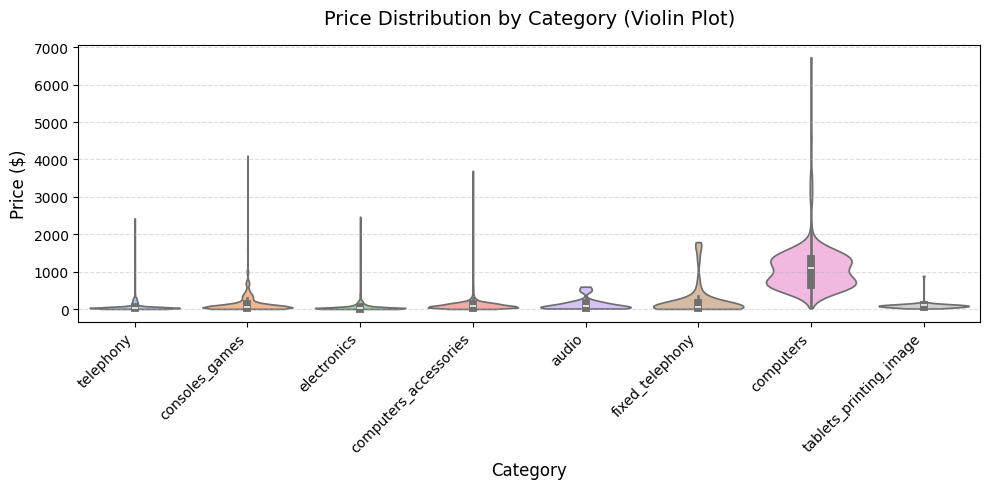

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.violinplot(
    data=order_digital,
    x='category',
    y='price',
    inner='box',        # 중앙 boxplot 표시
    cut=0,              # 데이터 영역 밖으로 밀도 확장 안함
    density_norm='width',      # 각 카테고리 폭 동일
    hue='category',
    palette='pastel'    # 부드러운 색상
)

plt.title('Price Distribution by Category (Violin Plot)', fontsize=14, pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [62]:
order_digital

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,category
6,00054e8431b9d7675808bcb819fb4a32,1,8d4f2bb7e93e6710a28f34fa83ee7d28,7040e82f899a04d1b434b795a43b4617,2017-12-14 12:10:31,19.90,11.85,telephony
16,0009c9a17f916a706d71784483a5d643,1,3f27ac8e699df3d300ec4a5d8c5cf0b2,fcb5ace8bcc92f75707dc0f01a27d269,2018-05-02 09:31:53,639.00,11.34,consoles_games
21,000e906b789b55f64edcb1f84030f90d,1,57d79905de06d8897872c551bfd09358,ea8482cd71df3c1969d7b9473ff13abc,2017-11-27 19:09:02,21.99,11.85,telephony
35,0014ae671de39511f7575066200733b7,1,23365beed316535b4105bd800c46670e,92eb0f42c21942b6552362b9b114707d,2017-05-29 03:15:24,16.50,14.10,telephony
36,0015ebb40fb17286bea51d4607c4733c,1,50fd2b788dc166edd20512370dac54df,8b321bb669392f5163d04c59e235e066,2018-01-18 09:11:24,21.90,15.10,electronics
...,...,...,...,...,...,...,...,...
112633,fff8286f77788ab8b55b2e5747fa7dd8,1,a2da86fa759178e9e58e54aa1a144e59,ea8482cd71df3c1969d7b9473ff13abc,2018-07-05 22:31:13,24.99,15.28,telephony
112634,fff8287bbae429a99bb7e8c21d151c41,1,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14,computers_accessories
112635,fff8287bbae429a99bb7e8c21d151c41,2,bee2e070c39f3dd2f6883a17a5f0da45,4e922959ae960d389249c378d1c939f5,2018-03-27 12:29:22,180.00,48.14,computers_accessories
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,computers_accessories


In [63]:
merged1 = pd.merge(order_digital[['order_id', 'category']], orders[['order_id', 'customer_id']], how='inner', on='order_id')

In [64]:
digital_order_customer = pd.merge(merged1, customers[['customer_id', 'customer_unique_id']], how='inner', on='customer_id')

In [65]:
# 재구매율 계산
grouped = digital_order_customer.groupby('customer_unique_id').agg(cnt_order=('customer_id', 'count'))
reorder_cond = grouped['cnt_order'] > 1
grouped[reorder_cond].size / grouped.size * 100

9.478987140395068

## 구매 가격 살펴보기

In [15]:
merged1 = pd.merge(orders, order_payments, how='inner', on='order_id')
merged2 = pd.merge(merged1, order_items, how='inner', on='order_id')
merged3 = pd.merge(order_items, order_payments, how='inner', on='order_id')
merged2

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117596,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,credit_card,3,195.00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554,2018-02-12 13:10:37,174.90,20.10
117597,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,credit_card,5,271.01,1,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48,2017-09-05 15:04:16,205.99,65.02
117598,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,credit_card,4,441.16,1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59
117599,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,credit_card,4,441.16,2,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48,2018-01-12 21:36:21,179.99,40.59


In [77]:
cond1 = merged3.duplicated(subset=['order_id', 'order_item_id'])

In [78]:
merged3[cond1]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
39,0016dfedd97fc2950e388d2971d718c7,1,4089861a1bd4685da70bddd6b4f974f1,a35124e2d763d7ca3fbe3b97d143200f,2017-05-05 10:05:12,49.75,20.80,1,credit_card,5,52.63
81,002f19a65a2ddd70a090297872e6d64e,1,9eae06d51aaa383b2bed5547a19d581c,1835b56ce799e6a4dc4eddc053f04066,2018-03-27 13:15:27,53.98,23.31,2,voucher,1,33.18
183,0071ee2429bc1efdc43aa3e073a5290e,1,00ffe57f0110d73fd84d162252b2c784,53e4c6e0f4312d4d2107a8c9cddf45cd,2018-01-26 14:17:41,179.98,12.46,2,voucher,1,92.44
242,009ac365164f8e06f59d18a08045f6c4,1,35557c68a22ecebcf066e25ca2ddc144,f8db351d8c4c4c22c6835c19a46f01b0,2017-11-29 00:11:24,16.90,15.10,6,voucher,1,4.17
243,009ac365164f8e06f59d18a08045f6c4,1,35557c68a22ecebcf066e25ca2ddc144,f8db351d8c4c4c22c6835c19a46f01b0,2017-11-29 00:11:24,16.90,15.10,1,credit_card,1,0.88
...,...,...,...,...,...,...,...,...,...,...,...
117424,ff978de32e717acd3b5abe1fb069d2b6,1,0829c25b4a3efca7651f07cd4b8e05bc,9f505651f4a6abe901a56cdc21508025,2017-12-18 09:57:24,27.99,21.15,3,voucher,1,0.66
117425,ff978de32e717acd3b5abe1fb069d2b6,1,0829c25b4a3efca7651f07cd4b8e05bc,9f505651f4a6abe901a56cdc21508025,2017-12-18 09:57:24,27.99,21.15,1,voucher,1,30.00
117438,ffa1dd97810de91a03abd7bd76d2fed1,1,2f178dc91b792930e1ff40a77a123506,75d34ebb1bd0bd7dde40dd507b8169c3,2017-06-06 22:42:56,434.99,20.32,1,credit_card,1,36.58
117443,ffa39020fe7c8a3e907320e1bec4b985,1,9e0e152552a1323f7e5dcf63d50cdae3,cc419e0650a3c5ba77189a1882b7556a,2017-11-10 18:55:13,56.99,14.15,1,credit_card,1,7.13


In [16]:
order_id = '00ac05fe0fc047c54418098eb64e3aaa'
merged3[merged3['order_id'] == order_id]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
274,00ac05fe0fc047c54418098eb64e3aaa,1,78efe838c04bbc568be034082200ac20,0241d4d5d36f10f80c644447315af0bd,2018-02-22 14:30:55,99.9,23.57,2,debit_card,1,123.47


In [82]:
order_payments['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'not_defined'],
      dtype=object)

In [70]:
orders.shape

(99441, 8)

In [69]:
merged1.shape

(103886, 12)

In [68]:
order_items.shape

(112650, 7)

In [67]:
merged2.shape

(117601, 18)

In [ ]:
merged2.groupby('order_id').agg({'price': 'sum'})